##### ***近似训练***
###### 由于在跳元模型中我们计算条件概率用的是softmax，但是它的弊端在于会将整个词表的词都考虑进去，导致计算量很大。所以为了减少开销，我们采用两种近似训练方法：负采样和分层softmax。
##### ***负采样***
###### 负采样修改了原先的目标函数，使其变成了：
$$P(D = 1 | w_c, w_o) = \sigma(w_o^Tv_c),$$
###### 其中$\sigma$是sigmoid激活函数，D表示这两个词是上下文-中心词的关系。让我们从最大化文本序列中所有这些事件的联合概率开始训练词嵌入。具体来说，给定长为T的文本序列，以$w_{(t)}$表示时间步t的词，并使上下文窗口为m，考虑最大化联合概率：
$$\prod_{t=1}^{T}\prod_{-m\leq j \leq m, j\neq 0} P(D = 1 | w_{(t)}, w_{(t+j)}).$$
###### 只考虑正样本的事件时，仅当所有词向量都等于无穷大时，联合概率才会等于1。为了使目标函数更有意义，负采样添加了从预定义分布中采样的负样本，也就是说从非上下文词中采样K个词，将它们作为负样本。其中用S和N分别表示正样本和负样本的集合。所以添加负采样后近似条件概率为：
$$P(w^{(t+j)}|w^{(t)})= P(D = 1|w^{(t)}, w^{(t+j)})\prod_{k=1, w_k\sim P(w)}^KP(D=0|w^{(t)}, w_k)$$
###### 损失函数为：
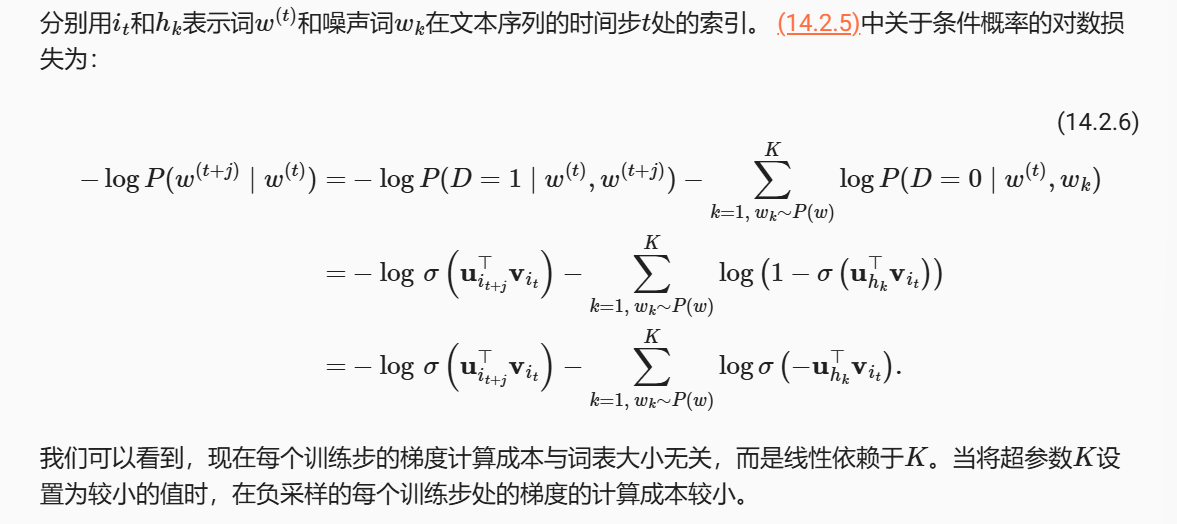
##### ***层序softmax***
###### 另一种近似的训练方法是层序softmax，使用二叉树这种数据结构，每个叶节点表示词表中的词，使用$L(w)$来表示从根节点到叶节点的路径节点数。所以就可将之前对全词表的softmax变换，转换为沿着一个二叉树走一条路径的二分类问题，每一步都在当前节点判断往左还是往右，而这个非叶子节点，也就是内部节点都有一个自己的向量u，此时我们会用当前词$v_c$和$u$做点积然后放进$\sigma$中得到一个概率，随后将$L(w)$个概率相乘得到当前词的选择概率，而最终词表内的词概率为1，所以也被看成另一种softmax。具体公式如下：
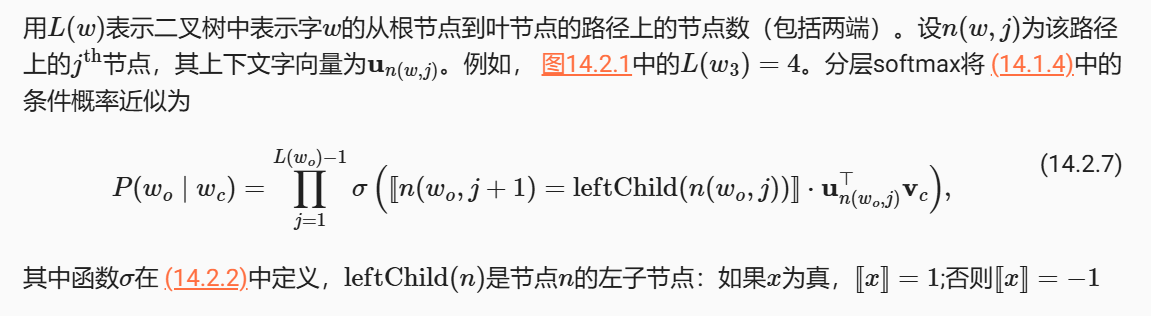